<a href="https://colab.research.google.com/github/Vyankatesh-ops/Advanced-Machine-Learning/blob/main/Experiment_No_5_AML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import torch
import torchvision
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

%config InlineBackend.figure_format = 'svg'
# Use 'seaborn-v0_8' instead of 'seaborn' for compatibility with newer Matplotlib versions
plt.style.use('seaborn-v0_8')

In [4]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

    except RuntimeError as e:
        print(e)

In [6]:
ratings_data = pd.read_csv('./ratings.csv')
movie_names_data = pd.read_csv('./movies.csv')

In [7]:
n_movies = len(movie_names_data)
n_user = len(ratings_data['userId'].unique())

In [8]:
ratings_data = pd.merge(ratings_data, movie_names_data, on='movieId', how='inner')

In [9]:
ratings_data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [10]:
from sklearn.preprocessing import LabelEncoder
import random
Y = ratings_data.rating
user_enc = LabelEncoder()
movie_enc = LabelEncoder()
X = np.array([user_enc.fit_transform(ratings_data.userId),
              movie_enc.fit_transform(ratings_data.title)]).T

In [11]:
user_enc.classes_[4], movie_enc.classes_[8871]

(np.int64(5), 'Toy Story (1995)')

In [12]:
for x, y in zip(X[:10], Y[:10]):
    print(list(x), y)

[np.int64(0), np.int64(8871)] 4.0
[np.int64(0), np.int64(3661)] 4.0
[np.int64(0), np.int64(3845)] 4.0
[np.int64(0), np.int64(7523)] 5.0
[np.int64(0), np.int64(9119)] 5.0
[np.int64(0), np.int64(3252)] 3.0
[np.int64(0), np.int64(1284)] 5.0
[np.int64(0), np.int64(1337)] 4.0
[np.int64(0), np.int64(7180)] 5.0
[np.int64(0), np.int64(1535)] 5.0


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [14]:


num_users = len(X)
num_movies = len(X)
from keras.layers import Input, Embedding, Flatten, Dot, Dense, Activation, Dropout
from keras.models import Model

def build_model():
    movie_input = Input(shape=[1], name="Book-Input")
    movie_embedding = Embedding(n_movies+1, 15, name="Book-Embedding")(movie_input)
    movie_vec = Flatten(name="Flatten-Books")(movie_embedding)

    user_input = Input(shape=[1], name="User-Input")
    user_embedding = Embedding(n_user+1, 15, name="User-Embedding")(user_input)
    user_vec = Flatten(name="Flatten-Users")(user_embedding)

    prod = Dot(name="Dot-Product", axes=1)([user_vec, movie_vec])

    prod = Dense(32)(prod)
    prod = Activation('relu')(prod)
    prod = Dropout(0.5)(prod)

    prod = Dense(16)(prod)
    prod = Activation('relu')(prod)
    prod = Dropout(0.5)(prod)
    prod = Dense(1)(prod)


    model = Model([user_input, movie_input], prod)
    model.compile('adam', 'mean_squared_error', metrics=['accuracy'])

    return model


model = build_model()

In [16]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='./checkpoint.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1)

history = model.fit([X_train[:, 0], X_train[:, 1]], Y_train,
            epochs=15,
            verbose=1,
            batch_size=64,
            validation_data=([X_test[:, 0], X_test[:, 1]], Y_test),
            callbacks=[model_checkpoint_callback])

Epoch 1/15
1254/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0232 - loss: 4.8069
Epoch 1: val_loss improved from None to 1.18601, saving model to ./checkpoint.weights.h5

Epoch 1: finished saving model to ./checkpoint.weights.h5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.0265 - loss: 2.8432 - val_accuracy: 0.0280 - val_loss: 1.1860
Epoch 2/15
1256/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0279 - loss: 1.7461
Epoch 2: val_loss improved from 1.18601 to 1.00109, saving model to ./checkpoint.weights.h5

Epoch 2: finished saving model to ./checkpoint.weights.h5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.0279 - loss: 1.6582 - val_accuracy: 0.0280 - val_loss: 1.0011
Epoch 3/15
1250/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0286 - loss: 1.2259
Epoch 3: val_loss improved from 1.00109 to 0.90889, saving model to ./checkpoint.weights.h5

Epoch 3: finished saving model to ./checkpoint.weights.h5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc

In [17]:
X_test[:5], Y_test[:5]

(array([[ 275, 4337],
        [ 598, 7425],
        [ 482,  334],
        [ 201, 3548],
        [ 273, 3540]]),
 41008    5.0
 94274    2.5
 77380    2.5
 29744    3.0
 40462    4.0
 Name: rating, dtype: float64)

In [18]:
predictions = model.predict([X_test[:5, 0], X_test[:5, 1]])
print(predictions,"\n\n", Y_test[:5].values)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
[[4.587338 ]
 [3.2736003]
 [3.8754628]
 [4.17951  ]
 [3.3346274]] 

 [5.  2.5 2.5 3.  4. ]


In [19]:
movie_enc.classes_[4]

"'Til There Was You (1997)"

In [21]:
def extract_true_ratings(user_id, X_data, Y_data):
    # Find indices where the userId matches the encoded user_id
    user_indices = np.where(X_data[:, 0] == user_id)[0]
    return Y_data.iloc[user_indices]

# Let's pick a user ID that exists in X_test
test_user_id = X_test[0, 0]
extract_true_ratings(test_user_id, X_test, Y_test)

,rating
41008,5.0
40989,4.0
40991,5.0
41015,5.0
40978,4.0


In [22]:
def predict_ratings(user_id, X_test):
    '''
    given user id predict all ratings for movies
    '''
    user_data = ratings_data[ratings_data['userId'] == user_id]
    movie_ids, movie_names, predictions, movie_genres = list(), list(), list(), list()
    i = 0
    for _id, movie_id in X_test:
        if user_id == X_test[i][0]:
            movie_ids.append(X_test[i, 1])
            movie_names.append(movie_enc.classes_[movie_id])
            pred = model.predict([ np.array([X_test[i, 0]]), np.array([X_test[i, 1]]) ])
            predictions.append(pred[0][0])
        i += 1
    return movie_ids, movie_names, movie_genres, predictions

In [24]:
test_user_id = 7
userid_rating_data = ratings_data[ratings_data['userId'] == test_user_id]
# userid_rating_data
movie_ids, movie_names, movie_genres, predictions = predict_ratings(test_user_id, X_test)
dictionary = {"user_id": [test_user_id]*len(movie_ids),
              "movie_id": movie_ids,
              "movie_name":movie_names,
              "predicted_ratings":predictions,
              "true_ratings": extract_true_ratings(test_user_id, X_test, Y_test)
              }
prediction_dataframe = pd.DataFrame.from_dict(dictionary, orient='index').transpose()
prediction_dataframe.sort_values('predicted_ratings', ascending=False)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


,user_id,movie_id,movie_name,predicted_ratings,true_ratings
5,7,7421,Schindler's List (1993),4.419326,5.0
3,7,1799,City Slickers II: The Legend of Curly's Gold (...,3.827206,1.0
4,7,2139,Dances with Wolves (1990),3.810742,5.0
0,7,6865,Pulp Fiction (1994),3.800784,4.0
1,7,7755,Sleepless in Seattle (1993),3.198439,3.0
2,7,7912,Speed (1994),3.033701,4.0


In [ ]:
#cpntent-filtering.ipynb
#from below

In [26]:
import sys
import pandas as pd
from sklearn.cluster import KMeans
movies_genres = pd.read_csv("./movie_genres.csv")
user_reviews = pd.read_csv("./user_reviews.csv")
movies_genres = movies_genres.drop("Unnamed: 0", axis=1)
movies_genres.head(5)

,movie_title,genre_action,genre_adventure,genre_animation,genre_biography,genre_comedy,genre_crime,genre_documentary,genre_drama,genre_family,...,genre_mystery,genre_news,genre_reality-tv,genre_romance,genre_sci-fi,genre_short,genre_sport,genre_thriller,genre_war,genre_western
0,The Net,1,0,0,0,0,1,0,1,0,...,1,0,0,0,0,0,0,1,0,0
1,Happily N'Ever After,0,1,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,Tomorrowland,1,1,0,0,0,0,0,0,1,...,1,0,0,0,1,0,0,0,0,0
3,American Hero,1,0,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,Das Boot,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,1,0


In [27]:
user_reviews = user_reviews.drop("Unnamed: 0", axis=1)
user_reviews.head(15)

,User,The Net,Happily N'Ever After,Tomorrowland,American Hero,Das Boot,Final Destination 3,Licence to Kill,The Hundred-Foot Journey,The Matrix,...,The Martian,Micmacs,Solomon and Sheba,In the Company of Men,Silent House,Big Fish,Get Real,Trading Places,DOA: Dead or Alive,Hey Arnold! The Movie
0,Vincent,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Edgar,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Addilyn,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Marlee,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Javier,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Marcus,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Mary,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,Rosalie,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,Giovanni,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,Kennedi,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,1.0,0.0


In [28]:
# user_reviews.describe()
users = list(user_reviews["User"])
user_reviews = user_reviews.drop("User", axis=1)
movie_titles = list(user_reviews.columns)
users_dict = dict(zip(users, range(0, 600)))
movies_genres = movies_genres.drop("movie_title", axis=1)
# users_dict
movies_genres

,movie_title,genre_action,genre_adventure,genre_animation,genre_biography,genre_comedy,genre_crime,genre_documentary,genre_drama,genre_family,...,genre_mystery,genre_news,genre_reality-tv,genre_romance,genre_sci-fi,genre_short,genre_sport,genre_thriller,genre_war,genre_western
0,The Net,1,0,0,0,0,1,0,1,0,...,1,0,0,0,0,0,0,1,0,0
1,Happily N'Ever After,0,1,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,Tomorrowland,1,1,0,0,0,0,0,0,1,...,1,0,0,0,1,0,0,0,0,0
3,American Hero,1,0,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,Das Boot,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,Big Fish,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1996,Get Real,0,0,0,0,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
1997,Trading Places,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1998,DOA: Dead or Alive,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


optimal K value is 5


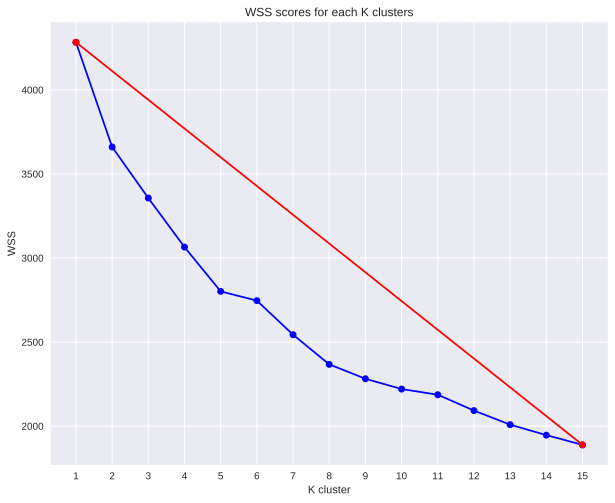

In [31]:
# Ensure movie_titles is defined from user_reviews columns if not already
movie_titles = list(user_reviews.columns)

# convert movie_titles to dictionary
movie_titles_dict = dict(zip(movie_titles, range(0, 2000)))
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import numpy as np

# function returns WSS score for k values from 1 to kmax
def calculate_WSS(points, kmax):
    sse = []
    for k in range(1, kmax+1):
        kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(points)
        centroids = kmeans.cluster_centers_
        pred_clusters = kmeans.predict(points)
        curr_sse = 0

        # calculate square of Euclidean distance of each point from its cluster center
        for i in range(len(points)):
            curr_center = centroids[pred_clusters[i]]
            curr_sse += np.sum((points[i] - curr_center) ** 2)
        sse.append(curr_sse)
    return sse

# Select only numerical columns for clustering
X_genres = movies_genres.select_dtypes(include=[np.number]).values
wss = calculate_WSS(X_genres, 15)

def plot_elbow(wss, kmax):
    k_clusters = range(1, kmax+1)
    plt.figure(figsize=(10, 8))
    plt.ylabel('WSS')
    plt.xlabel('K cluster')
    plt.plot(k_clusters, wss, 'bo-')
    plt.plot((k_clusters[0], k_clusters[-1]), (wss[0], wss[-1]), 'ro-')
    plt.xticks(k_clusters)
    plt.title('WSS scores for each K clusters')
    plt.show()

def optimum_k(wcss, n_clusters):
    k_clusters = range(1, n_clusters+1)
    x1, y1 = 1, wcss[0]
    x2, y2 = len(wcss), wcss[-1]
    distances = []
    for i in range(len(wcss)):
        x0, y0 = k_clusters[i], wcss[i]
        numerator = abs((y2-y1)*x0 - (x2-x1)*y0 + x2*y1 - y2*x1)
        denominator = np.sqrt((y2 - y1)**2 + (x2 - x1)**2)
        distances.append(numerator/denominator)
    return distances, distances.index(max(distances)) + 1

distances, k_opt = optimum_k(wss, 15)
print('optimal K value is', k_opt)
plot_elbow(wss, 15)

In [33]:
km = KMeans(n_clusters=k_opt, n_init='auto', random_state=42)
# Use the numerical array X_genres instead of the full DataFrame
km.fit(X_genres)

KMeans(n_clusters=5, random_state=42)

In [35]:
# Load original movies to keep titles
movies_with_clusters = pd.read_csv('./movie_genres.csv')
if 'Unnamed: 0' in movies_with_clusters.columns:
    movies_with_clusters = movies_with_clusters.drop('Unnamed: 0', axis=1)

# Assign cluster labels
movies_with_clusters['cluster'] = km.labels_

# Show cluster distribution
print("Number of movies per cluster:")
print(movies_with_clusters['cluster'].value_counts().sort_index())

# Display sample movies from each cluster
movies_with_clusters[['movie_title', 'cluster']].head(10)

Number of movies per cluster:
cluster
0    293
1    614
2    331
3    448
4    314
Name: count, dtype: int64


,movie_title,cluster
0,The Net,3
1,Happily N'Ever After,4
2,Tomorrowland,4
3,American Hero,1
4,Das Boot,3
5,Final Destination 3,1
6,Licence to Kill,4
7,The Hundred-Foot Journey,1
8,The Matrix,4
9,Creature,3


In [41]:
# Predict clusters using only numerical data
cluster_labels = km.predict(X_genres)

# Ensure user_reviews only contains movie ratings (numeric columns)
if 'User' in user_reviews.columns:
    user_reviews_numeric = user_reviews.drop('User', axis=1)
else:
    user_reviews_numeric = user_reviews

def extract_unrated_movies(df, user_index):
    '''
    extract movie names that user did not rate at all.
    '''
    unrated_movies = list()
    user_ratings = df.iloc[user_index]
    for movie in df.columns:
        try:
            if float(user_ratings[movie]) == 0:
                unrated_movies.append(movie)
        except (ValueError, TypeError):
            continue
    return unrated_movies

def rate_movie(cluster_point, cluster_labels, user_index, df):
    '''
    calculate average rating for a cluster
    '''
    scores = list()
    for movie_index, cluster in enumerate(cluster_labels):
        if cluster == cluster_point:
            rating = df.iloc[user_index, movie_index]
            try:
                val = float(rating)
                if val != 0:
                    scores.append(val)
            except (ValueError, TypeError):
                continue
    return np.mean(scores) if len(scores)!=0 else 1

def movie_predictor(movie_names, user_name, movie_titles_dict, cluster_labels, df):
    '''
    output the predicted ratings for each movie.
    '''
    movie_scores = list()
    valid_movies = list()
    for movie in movie_names:
        # Skip movies not found in the genre dictionary to avoid KeyErrors
        if movie in movie_titles_dict:
            cluster_point = cluster_labels[movie_titles_dict[movie]]
            score = rate_movie(cluster_point, cluster_labels, users_dict[user_name], df)
            movie_scores.append(int(np.round(score)))
            valid_movies.append(movie)
    return valid_movies, movie_scores

user_name = 'Vincent'
unrated_movies = extract_unrated_movies(user_reviews_numeric, users_dict[user_name])
valid_movies, scores = movie_predictor(unrated_movies, user_name, movie_titles_dict, cluster_labels, user_reviews_numeric)

dt_Vincent = pd.DataFrame({'movies': valid_movies, 'ratings': scores}).sort_values(by=['ratings'], ascending=False)

print(f"Top 5 Recommendations for {user_name}:")
print(dt_Vincent.head(5))

Top 5 Recommendations for Vincent:
                    movies  ratings
1959    DOA: Dead or Alive        4
0                  The Net        4
1     Happily N'Ever After        4
1958        Trading Places        4
3            American Hero        4


In [37]:
# Re-creating the users dictionary mapping from the original data
original_user_reviews = pd.read_csv('./user_reviews.csv')
users_list = list(original_user_reviews['User'])
users_dict = {name: i for i, name in enumerate(users_list)}

print(f"Successfully mapped {len(users_dict)} users.")

Successfully mapped 600 users.


In [43]:
user_name = 'Edgar'
# Extract unrated movies
unrated_movies = extract_unrated_movies(user_reviews, users_dict[user_name])

# Fix: Added 'user_reviews' as the 5th argument and unpacked both returned values
valid_movies, scores = movie_predictor(unrated_movies, user_name, movie_titles_dict, cluster_labels, user_reviews)

# Create the recommendations dataframe
dt_Edgar = pd.DataFrame({'movies': valid_movies, 'ratings': scores}).sort_values(by=['ratings'], ascending=False)

print(f"Top 5 Recommendations for {user_name}:")
display(dt_Edgar.head(5))
list(dt_Edgar.movies[:5])

Top 5 Recommendations for Edgar:


,movies,ratings
1959,The Torture Chamber of Dr. Sadism,5
1208,The Phantom of the Opera,5
1205,Crossroads,5
1200,Khiladi 786,5
1950,Mrs Henderson Presents,5


['The Torture Chamber of Dr. Sadism',
 'The Phantom of the Opera',
 'Crossroads',
 'Khiladi 786',
 'Mrs Henderson Presents']

In [45]:
user_name = 'Addilyn'
# Extract unrated movies
unrated_movies = extract_unrated_movies(user_reviews, users_dict[user_name])

# Fix: Added 'user_reviews' as the 5th argument and unpacked both returned values
valid_movies, scores = movie_predictor(unrated_movies, user_name, movie_titles_dict, cluster_labels, user_reviews)

# Create the recommendations dataframe
dt_Addilyn = pd.DataFrame({'movies': valid_movies, 'ratings': scores}).sort_values(by=['ratings'], ascending=False)

print(f"Top 5 Recommendations for {user_name}:")
display(dt_Addilyn.head(5))
list(dt_Addilyn.movies[:5])

Top 5 Recommendations for Addilyn:


,movies,ratings
1962,DOA: Dead or Alive,4
0,The Net,4
1,Happily N'Ever After,4
2,Tomorrowland,4
3,American Hero,4


['DOA: Dead or Alive',
 'The Net',
 "Happily N'Ever After",
 'Tomorrowland',
 'American Hero']

In [47]:
user_name = 'Marlee'
# Extract unrated movies
unrated_movies = extract_unrated_movies(user_reviews, users_dict[user_name])

# Fix: Added 'user_reviews' as the 5th argument and unpacked both returned values
valid_movies, scores = movie_predictor(unrated_movies, user_name, movie_titles_dict, cluster_labels, user_reviews)

# Create the recommendations dataframe using the correctly unpacked lists
dt_Marlee = pd.DataFrame({'movies': valid_movies, 'ratings': scores}).sort_values(by=['ratings'], ascending=False)

print(f"Top 5 Recommendations for {user_name}:")
display(dt_Marlee.head(5))
list(dt_Marlee.movies[:5])

Top 5 Recommendations for Marlee:


,movies,ratings
30,Novocaine,4
1951,Force 10 from Navarone,4
1950,Jesus' Son,4
15,The Blues Brothers,4
29,Little Children,4


['Novocaine',
 'Force 10 from Navarone',
 "Jesus' Son",
 'The Blues Brothers',
 'Little Children']

In [49]:
user_name = 'Javier'
# Extract unrated movies
unrated_movies = extract_unrated_movies(user_reviews, users_dict[user_name])

# Fix: Added 'user_reviews' as the 5th argument and unpacked both returned values
valid_movies, scores = movie_predictor(unrated_movies, user_name, movie_titles_dict, cluster_labels, user_reviews)

# Create the recommendations dataframe
dt_Javier = pd.DataFrame({'movies': valid_movies, 'ratings': scores}).sort_values(by=['ratings'], ascending=False)

print(f"Top 5 Recommendations for {user_name}:")
display(dt_Javier.head(5))
list(dt_Javier.movies[:5])

Top 5 Recommendations for Javier:


,movies,ratings
9,Creature,4
1925,Paint Your Wagon,4
22,The Messengers,4
23,Heaven Is for Real,4
24,The Iceman,4


['Creature',
 'Paint Your Wagon',
 'The Messengers',
 'Heaven Is for Real',
 'The Iceman']

In [50]:
dt_Javier.head(5)
list(dt_Javier.movies[:5])

['Creature',
 'Paint Your Wagon',
 'The Messengers',
 'Heaven Is for Real',
 'The Iceman']